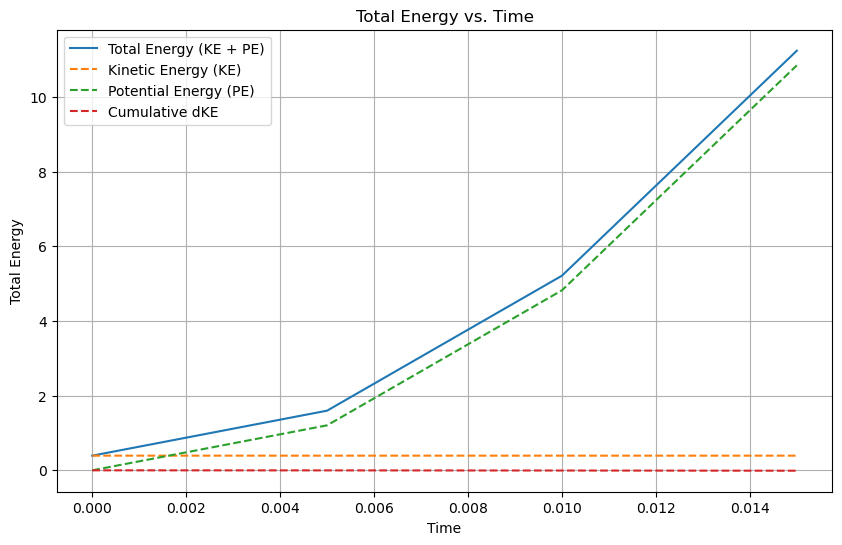

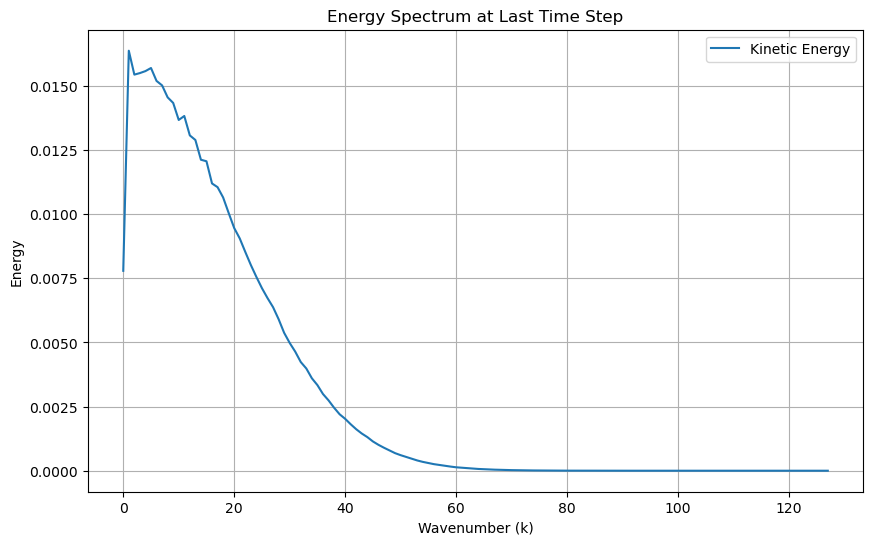

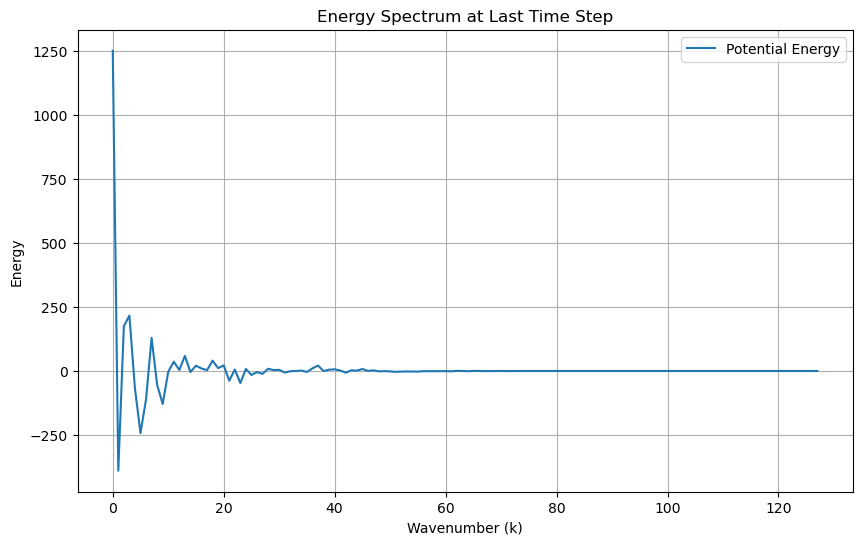

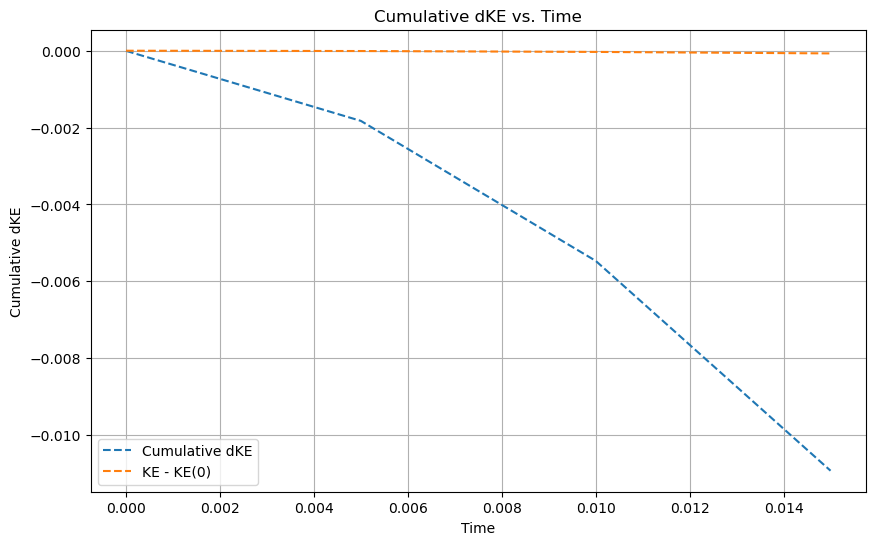

In [13]:
# read especData.dat in the output
import numpy as np
import matplotlib.pyplot as plt

# Load the data from the file
with open('../../output/especData.dat', 'r') as f:
    lines = f.readlines()

# Process the data
times = []
ke_data = []
pe_data = []
dke_data = []

for i in range(0, len(lines), 3):
    ke_line = lines[i].split()
    pe_line = lines[i+1].split()
    dke_line = lines[i+2].split()

    # The first element is the label, the second is the time
    times.append(float(ke_line[1]))
    ke_data.append([float(x) for x in ke_line[2:]])
    pe_data.append([float(x) for x in pe_line[2:]])
    dke_data.append([float(x) for x in dke_line[2:]])

ke_data = np.array(ke_data)
pe_data = np.array(pe_data)
dke_data = np.array(dke_data)
times = np.array(times)

# Calculate total energy
total_ke = np.sum(ke_data, axis=1)
total_pe = np.sum(pe_data, axis=1)
total_pe = total_pe - total_pe[0]  # Normalize potential energy
total_energy = total_ke + total_pe

# Cumsum for total_dke
total_dke = np.sum(dke_data, axis=1)
total_dke = np.cumsum(total_dke)

# Plot total energy vs. time
plt.figure(figsize=(10, 6))
plt.plot(times, total_energy, label='Total Energy (KE + PE)')
plt.plot(times, total_ke, label='Kinetic Energy (KE)', linestyle='--')
plt.plot(times, total_pe, label='Potential Energy (PE)', linestyle='--')
plt.plot(times, total_dke, label='Cumulative dKE', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Total Energy')
plt.title('Total Energy vs. Time')
plt.legend()
plt.grid(True)
plt.show()

# Plot energy spectrum at the last time step
last_time_step_ke = ke_data[-1]
last_time_step_pe = pe_data[-1]
k_wavenumbers = np.arange(len(last_time_step_ke))

plt.figure(figsize=(10, 6))
plt.plot(k_wavenumbers, last_time_step_ke, label='Kinetic Energy')
# plt.plot(k_wavenumbers, last_time_step_pe, label='Potential Energy')
plt.xlabel('Wavenumber (k)')
plt.ylabel('Energy')
plt.title('Energy Spectrum at Last Time Step')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(k_wavenumbers, last_time_step_pe, label='Potential Energy')
plt.xlabel('Wavenumber (k)')
plt.ylabel('Energy')
plt.title('Energy Spectrum at Last Time Step')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(times, total_dke, label='Cumulative dKE', linestyle='--')
plt.plot(times, total_ke-total_ke[0], label='KE - KE(0)', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Cumulative dKE')
plt.title('Cumulative dKE vs. Time')
plt.legend()
plt.grid(True)
plt.show()
